LOAN APPROVAL PREDICTION: SMOTE + PCA + SVM

📁 Loading dataset...
Dataset shape: (5000, 11)
Original class distribution: Counter({np.int64(0): 4520, np.int64(1): 480})

🔄 Step 1: Applying SMOTE...
----------------------------------------------------------------------
Original distribution: Class 0: 4520, Class 1: 480
After SMOTE: Class 0: 4520, Class 1: 4520

📊 Step 2: Normalizing data...
----------------------------------------------------------------------
Data normalized successfully!

🎯 Step 3: Applying PCA (dimensionality reduction to 2D)...
----------------------------------------------------------------------
Reduced dimensions: 2D

📈 Visualizing PCA results...
✂️ Step 4: Splitting data (80% train, 20% test)...
----------------------------------------------------------------------
Training set: 7232 samples
Test set: 1808 samples

🤖 Step 5: Training SVM with Gradient Descent (Linear Kernel)...
----------------------------------------------------------------------
Epoch 100/500, 

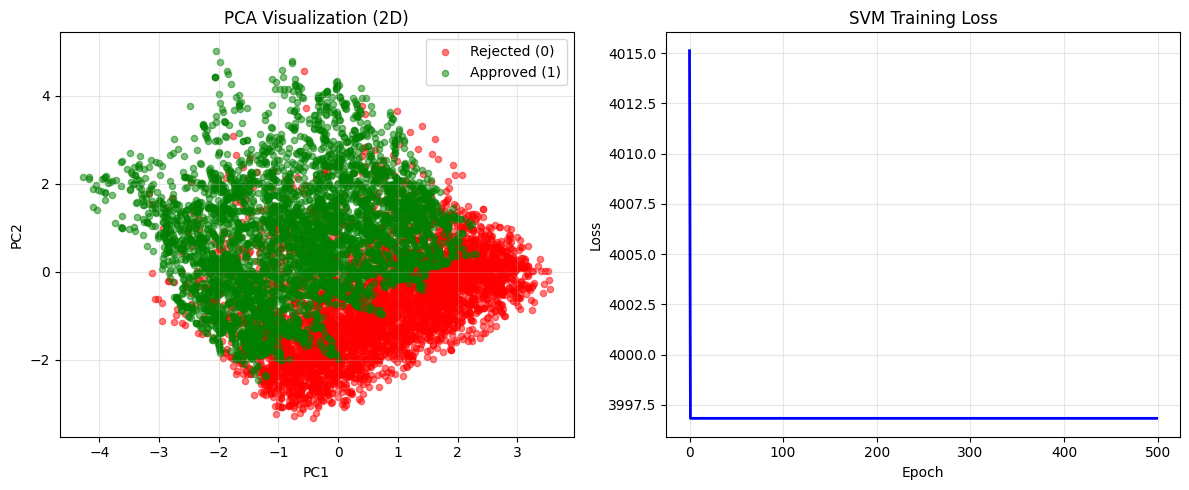

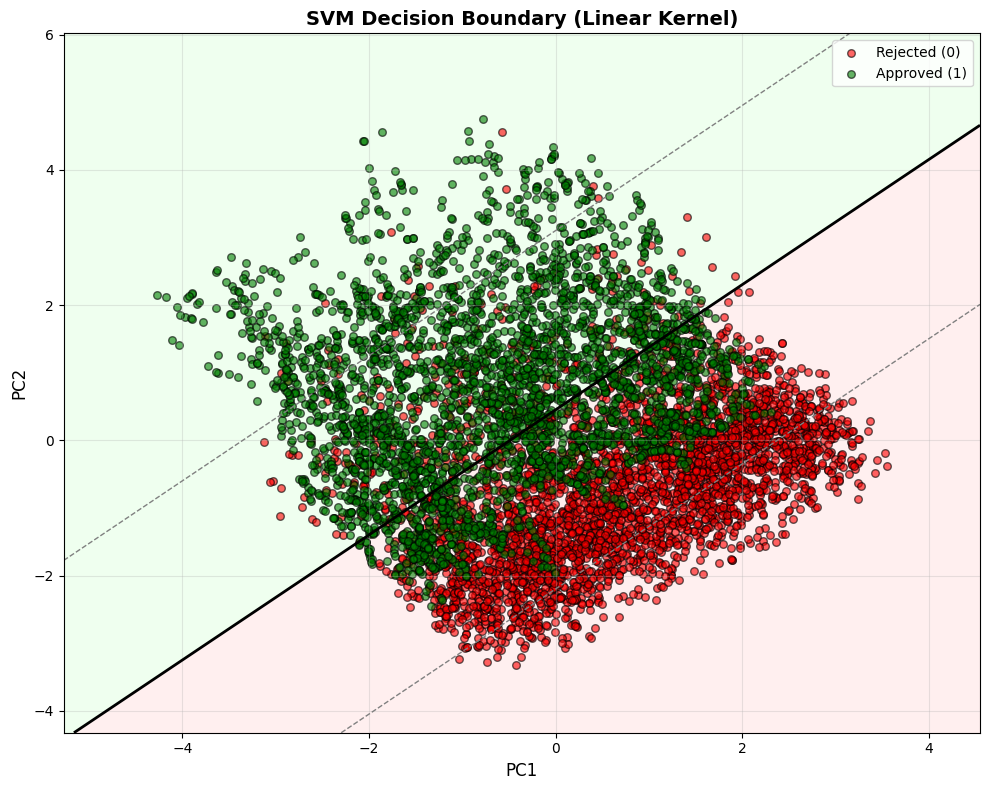

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ==================== SMOTE IMPLEMENTATION ====================
class SMOTE:
    def __init__(self, k_neighbors=5, sampling_ratio=0.5):
        self.k_neighbors = k_neighbors
        self.sampling_ratio = sampling_ratio
    
    def fit_resample(self, X, y):
        """
        Apply SMOTE to balance the dataset
        """
        X = np.array(X)
        y = np.array(y)
        
        # Separate minority and majority classes
        minority_indices = np.where(y == 1)[0]
        majority_indices = np.where(y == 0)[0]
        
        X_minority = X[minority_indices]
        X_majority = X[majority_indices]
        
        # Calculate number of synthetic samples needed
        num_majority = len(X_majority)
        num_minority = len(X_minority)
        # num_synthetic = int(num_majority * self.sampling_ratio) - num_minority
        num_synthetic = num_majority - num_minority
        
        if num_synthetic <= 0:
            return X, y
        
        print(f"Original distribution: Class 0: {num_majority}, Class 1: {num_minority}")
        
        # Generate synthetic samples
        synthetic_samples = []
        
        for _ in range(num_synthetic):
            # Randomly select a minority sample
            idx = np.random.randint(0, len(X_minority))
            sample = X_minority[idx]
            
            # Find k nearest neighbors
            distances = []
            for i, neighbor in enumerate(X_minority):
                if i != idx:
                    dist = np.sqrt(np.sum((sample - neighbor) ** 2))
                    distances.append((i, dist))
            
            # Sort by distance and get k nearest
            distances.sort(key=lambda x: x[1])
            k_nearest = distances[:min(self.k_neighbors, len(distances))]
            
            # Randomly select one of k nearest neighbors
            neighbor_idx = k_nearest[np.random.randint(0, len(k_nearest))][0]
            neighbor = X_minority[neighbor_idx]
            
            # Generate synthetic sample
            gap = np.random.random()
            synthetic = sample + gap * (neighbor - sample)
            synthetic_samples.append(synthetic)
        
        # Combine original and synthetic data
        X_resampled = np.vstack([X, np.array(synthetic_samples)])
        y_resampled = np.hstack([y, np.ones(len(synthetic_samples))])
        
        print(f"After SMOTE: Class 0: {num_majority}, Class 1: {num_minority + num_synthetic}")
        
        return X_resampled, y_resampled


# ==================== PCA IMPLEMENTATION ====================
class PCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance = None
    
    def fit(self, X):
        """
        Fit PCA on the data
        """
        X = np.array(X)
        
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # Compute covariance matrix
        cov_matrix = np.cov(X_centered.T)
        
        # Find eigenvectors using power iteration
        n_features = X.shape[1]
        self.components = []
        
        for comp in range(self.n_components):
            # Initialize random vector
            v = np.random.randn(n_features)
            v = v / np.linalg.norm(v)
            
            # Power iteration
            for _ in range(100):
                v_new = cov_matrix @ v
                
                # Orthogonalize against previous components
                for prev_comp in self.components:
                    v_new = v_new - (v_new @ prev_comp) * prev_comp
                
                # Normalize
                norm = np.linalg.norm(v_new)
                if norm < 1e-10:
                    break
                v = v_new / norm
            
            self.components.append(v)
        
        self.components = np.array(self.components)
        
        return self
    
    def transform(self, X):
        """
        Transform data to principal components
        """
        X = np.array(X)
        X_centered = X - self.mean
        return X_centered @ self.components.T
    
    def fit_transform(self, X):
        """
        Fit and transform in one step
        """
        self.fit(X)
        return self.transform(X)


# ==================== SVM IMPLEMENTATION ====================
class SVM:
    def __init__(self, learning_rate=0.01, epochs=500, C=1.0):
        self.lr = learning_rate
        self.epochs = epochs
        self.C = C
        self.w = None
        self.b = None
        self.losses = []
    
    def fit(self, X, y):
        """
        Train SVM using gradient descent with linear kernel
        """
        X = np.array(X)
        y = np.array(y)
        
        # Convert labels to -1 and 1
        y = np.where(y == 0, -1, 1)
        
        n_samples, n_features = X.shape
        
        # Initialize weights and bias
        self.w = np.zeros(n_features)
        self.b = 0
        
        # Gradient descent
        for epoch in range(self.epochs):
            total_loss = 0
            
            for i in range(n_samples):
                xi = X[i]
                yi = y[i]
                
                # Calculate decision function
                decision = np.dot(self.w, xi) + self.b
                margin = yi * decision
                
                # Update weights based on hinge loss
                if margin < 1:
                    # Misclassified or within margin
                    self.w = self.w - self.lr * (self.w - self.C * yi * xi)
                    self.b = self.b - self.lr * (-self.C * yi)
                    total_loss += 1 - margin
                else:
                    # Correctly classified
                    self.w = self.w - self.lr * self.w
            
            # Calculate total loss (with regularization)
            reg_loss = 0.5 * np.dot(self.w, self.w)
            total_loss = reg_loss + self.C * total_loss
            self.losses.append(total_loss)
            
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch + 1}/{self.epochs}, Loss: {total_loss:.4f}")
        
        return self
    
    def predict(self, X):
        """
        Predict class labels
        """
        X = np.array(X)
        decision = X @ self.w + self.b
        return np.where(decision >= 0, 1, 0)
    
    def decision_function(self, X):
        """
        Calculate decision function values
        """
        X = np.array(X)
        return X @ self.w + self.b


# ==================== EVALUATION METRICS ====================
def calculate_metrics(y_true, y_pred):
    """
    Calculate classification metrics
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn
    }


# ==================== DATA NORMALIZATION ====================
def normalize_data(X):
    """
    Normalize features to zero mean and unit variance
    """
    X = np.array(X)
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    std[std == 0] = 1  # Avoid division by zero
    
    X_normalized = (X - mean) / std
    return X_normalized, mean, std


# ==================== MAIN PIPELINE ====================
def main():
    print("=" * 70)
    print("LOAN APPROVAL PREDICTION: SMOTE + PCA + SVM")
    print("=" * 70)
    print()
    
    # Load data
    print("📁 Loading dataset...")
    df = pd.read_csv('dataset/bank_personal_loan_data.csv')
    
    # Prepare features and target
    features = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 
                'Education', 'Mortgage', 'Securities Account', 
                'CD Account', 'Online', 'CreditCard']
    
    X = df[features].values
    y = df['Personal Loan'].values
    
    print(f"Dataset shape: {X.shape}")
    print(f"Original class distribution: {Counter(y)}")
    print()
    
    # Step 1: Apply SMOTE
    print("🔄 Step 1: Applying SMOTE...")
    print("-" * 70)
    smote = SMOTE(k_neighbors=5, sampling_ratio=0.5)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    print()
    
    # Step 2: Normalize data
    print("📊 Step 2: Normalizing data...")
    print("-" * 70)
    X_normalized, mean, std = normalize_data(X_resampled)
    print("Data normalized successfully!")
    print()
    
    # Step 3: Apply PCA
    print("🎯 Step 3: Applying PCA (dimensionality reduction to 2D)...")
    print("-" * 70)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_normalized)
    print(f"Reduced dimensions: {X_pca.shape[1]}D")
    print()
    
    # Visualize PCA
    print("📈 Visualizing PCA results...")
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(X_pca[y_resampled == 0, 0], X_pca[y_resampled == 0, 1], 
                c='red', label='Rejected (0)', alpha=0.5, s=20)
    plt.scatter(X_pca[y_resampled == 1, 0], X_pca[y_resampled == 1, 1], 
                c='green', label='Approved (1)', alpha=0.5, s=20)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA Visualization (2D)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Step 4: Train-Test Split
    print("✂️ Step 4: Splitting data (80% train, 20% test)...")
    print("-" * 70)
    
    # Shuffle data
    indices = np.arange(len(X_pca))
    np.random.shuffle(indices)
    
    split_idx = int(0.8 * len(X_pca))
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]
    
    X_train = X_pca[train_indices]
    y_train = y_resampled[train_indices]
    X_test = X_pca[test_indices]
    y_test = y_resampled[test_indices]
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print()
    
    # Step 5: Train SVM
    print("🤖 Step 5: Training SVM with Gradient Descent (Linear Kernel)...")
    print("-" * 70)
    svm = SVM(learning_rate=0.01, epochs=500, C=1.0)
    svm.fit(X_train, y_train)
    print()
    
    # Plot training loss
    plt.subplot(1, 2, 2)
    plt.plot(svm.losses, color='blue', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('SVM Training Loss')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('pca_and_loss.png', dpi=300, bbox_inches='tight')
    print("📊 PCA and Loss visualization saved as 'pca_and_loss.png'")
    print()
    
    # Step 6: Evaluate Model
    print("📊 Step 6: Evaluating Model Performance...")
    print("-" * 70)
    
    # Predictions
    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)
    
    # Calculate metrics
    train_metrics = calculate_metrics(y_train, y_train_pred)
    test_metrics = calculate_metrics(y_test, y_test_pred)
    
    print("\n🎓 TRAINING SET PERFORMANCE:")
    print(f"  Accuracy:  {train_metrics['accuracy']*100:.2f}%")
    print(f"  Precision: {train_metrics['precision']*100:.2f}%")
    print(f"  Recall:    {train_metrics['recall']*100:.2f}%")
    print(f"  F1-Score:  {train_metrics['f1']*100:.2f}%")
    print(f"  Confusion Matrix: TP={train_metrics['tp']}, TN={train_metrics['tn']}, "
          f"FP={train_metrics['fp']}, FN={train_metrics['fn']}")
    
    print("\n🧪 TEST SET PERFORMANCE:")
    print(f"  Accuracy:  {test_metrics['accuracy']*100:.2f}%")
    print(f"  Precision: {test_metrics['precision']*100:.2f}%")
    print(f"  Recall:    {test_metrics['recall']*100:.2f}%")
    print(f"  F1-Score:  {test_metrics['f1']*100:.2f}%")
    print(f"  Confusion Matrix: TP={test_metrics['tp']}, TN={test_metrics['tn']}, "
          f"FP={test_metrics['fp']}, FN={test_metrics['fn']}")
    
    print("\n⚙️ MODEL PARAMETERS:")
    print(f"  Weights (w): {svm.w}")
    print(f"  Bias (b): {svm.b:.4f}")
    
    # Visualize decision boundary
    print("\n📈 Creating decision boundary visualization...")
    plt.figure(figsize=(10, 8))
    
    # Create mesh
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict on mesh
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and margins
    plt.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf], 
                 colors=['#ffcccc', '#ccffcc'], alpha=0.3)
    plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
    plt.contour(xx, yy, Z, levels=[-1, 1], colors='gray', 
                linestyles='--', linewidths=1)
    
    # Plot training points
    plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
                c='red', label='Rejected (0)', alpha=0.6, s=30, edgecolors='black')
    plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
                c='green', label='Approved (1)', alpha=0.6, s=30, edgecolors='black')
    
    plt.xlabel('PC1', fontsize=12)
    plt.ylabel('PC2', fontsize=12)
    plt.title('SVM Decision Boundary (Linear Kernel)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('svm_decision_boundary.png', dpi=300, bbox_inches='tight')
    print("📊 Decision boundary saved as 'svm_decision_boundary.png'")
    
    print("\n" + "=" * 70)
    print("✅ Analysis completed successfully!")
    print("=" * 70)
    
    plt.show()


if __name__ == "__main__":
    main()